# 16 Text generation (Mini-C4)

In [1]:
import os
import sys
import json
import pathlib
from functools import partial

import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt

os.environ["KERAS_BACKEND"] = "jax"
# Free up more GPU memory on the Jax and TensorFlow backends.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

import keras
import keras_hub
import kagglehub

keras.config.set_dtype_policy("mixed_float16")

from IPython.display import clear_output
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [2]:
def plot_history(history, metric):
    accuracy = history.history[metric]
    val_accuracy = history.history[f"val_{metric}"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "r--", label=f"Training {metric}")
    plt.plot(epochs, val_accuracy, "b", label=f"Validation {metric}")
    plt.title(f"Training and validation {metric}")
    plt.legend()
    plt.show()

---

## Training a mini-GPT

In [3]:
TEXTGEN_DIR = pathlib.Path("text-generation")
TEXTGEN_DIR.mkdir(exist_ok=True)

DATASET_DIR = pathlib.Path(TEXTGEN_DIR / "datasets")
DATASET_DIR.mkdir(exist_ok=True)

MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

#### Mini-C4

A mini-version of [C4, "a colossal, cleaned version of Common Crawl's web crawl corpus"](https://huggingface.co/datasets/allenai/c4) (it's still ~3.7Gb of data unzipped, but the original has TBs of data).

In [4]:
MODEL_NAME = "mini-c4"

_ = keras.utils.get_file(
    fname="mini-c4",
    origin=(
        "https://hf.co/datasets/mattdangerw/mini-c4/resolve/main/mini-c4.zip"
    ),
    cache_dir=TEXTGEN_DIR,
    cache_subdir=DATASET_DIR.name,
    extract=True,
)
DS_DIR = DATASET_DIR / "mini-c4" / "mini-c4"

1505728294/1505728294 ━━━━━━━━━━━━━━━━━━━━ 62s 0us/step


##### A peep into the dataset

In [5]:
with open(DS_DIR / "shard0.txt", "r") as f:
    print(f.readline().replace("\\n", "\n")[:159])

Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. 


### Tokenization

For the tokenization, we use [`sentencepiece` library](https://github.com/google/sentencepiece), a dedicated tokenization library developed by Google.

[keras_hub.tokenizers.SentencePieceTokenizer](https://keras.io/keras_hub/api/tokenizers/sentence_piece_tokenizer/)

If you want to train your own tokenizer on Mini-C4, see [`lectures/09.more/mini-c4-tokenization.py`](https://github.com/jchwenger/DLWP/blob/main/lectures/09.more/mini-c4-tokenization.py) (in the current directory).

In [6]:
vocabulary_file = keras.utils.get_file(
    origin="https://hf.co/mattdangerw/spiece/resolve/main/vocabulary.proto",
    cache_dir=MODELS_DIR,
    cache_subdir="",
)
tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(vocabulary_file)

499723/499723 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##### Test

In [7]:
tokens = tokenizer.tokenize("The quick brown fox.")
print(tokens)
print(tokenizer.detokenize(tokens))

tf.Tensor([  450  4996 17354  1701 29916 29889], shape=(6,), dtype=int32)
The quick brown fox.


#### Finalize our dataset

In [8]:
BATCH_SIZE = 64
SEQUENCE_LENGTH = 256

# some customization for loading the files
def read_file(filename):
    lines = tf.data.TextLineDataset(filename)
    # '\n' are escaped in the dataset <-> one multiline document per line
    lines = lines.map(lambda x: tf.strings.regex_replace(x, r"\\n", "\n"))
    # each line is a 'document' -> append the 'end of document' token
    lines = lines.map(lambda x: tf.strings.join([x, "<|endoftext|>"]))
    return lines

files = [str(file) for file in DS_DIR.glob("*.txt")]
ds = tf.data.Dataset.from_tensor_slices(files)
# this will read/load files (specific `read_file` for custom or mini-c4)
ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)
# see: https://claude.ai/share/4277a644-4808-4aa3-8b6e-a005d9586014
ds = ds.map(tokenizer, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.rebatch(SEQUENCE_LENGTH + 1, drop_remainder=True)

# IMPORTANT: we now shift the sequence, x[:-1], x[1:], so that each timestep allows us to predict
# the next one (causal-masking in the transformer allows us to learn them all in parallel)
ds = ds.map(lambda x: (x[:-1], x[1:]))
ds = ds.batch(BATCH_SIZE).prefetch(8)

In [9]:
# in the book, for Mini-C4: 58746
# you can use the same with mini-c4, but it is slow...
# num_batches = ds.reduce(0, lambda count, _: count + 1).numpy().item()
num_batches = 59309

print(f"Number of train batches: {num_batches}")

num_val_batches = min(500, num_batches//10)
print(f"Number of val batches: {num_val_batches}")
num_train_batches = num_batches - num_val_batches

# create our train/val dataset
val_ds = ds.take(num_val_batches).repeat()
train_ds = ds.skip(num_val_batches).repeat()

Number of train batches: 59309
Number of val batches: 500


##### Test

In [10]:
for (x, y) in train_ds.take(1):
    print(f"{x.shape = }, {y.shape = }")
    print()
    print(x[0, :10])
    print(y[0, :10])
    print("---")
    print(tokenizer.detokenize(x)[0])
    print("---")

x.shape = TensorShape([64, 256]), y.shape = TensorShape([64, 256])

tf.Tensor([22937 14853 30010 29879  1856  3268 29889   450  2969  1244], shape=(10,), dtype=int32)
tf.Tensor([14853 30010 29879  1856  3268 29889   450  2969  1244   338], shape=(10,), dtype=int32)
---
literary magazine’s web site. The idea here is to seek out places that seem receptive to the kind of poems you write.
· Cover letters should be brief, professional, have your contact information, list the work you are submitting, and tell a little about yourself. Follow strictly the most current submission guidelines you can find. If possible and appropriate, address the poetry editor by name in your cover letter. It is probably a bad idea to list more than 3 to 5 of your previous publications.
This advice seems very good to me, especially the submission suggestions.
Thanks for the Becoming the Villainess write-up, Gerald! PS I finally added you to my blog roll.<|endoftext|> The short stories in Gabriela Torres Olivares’

### Baseline

We are using the same 'rough' metric, the accuracy, and we can compute the entropy of the dataset for the loss.

In [11]:
# see: https://chatgpt.com/share/69b2a232-8e98-8005-bfe5-91681b20c864
# get all the tokens
labels = tf.concat([seq for seq, _ in ds.take(num_val_batches)], axis=0)
# turn into bins
counts = tf.math.bincount(labels)
# turn into probs
probs = counts / tf.reduce_sum(counts)

In [12]:
likeliest_class = keras.ops.argmax(probs).numpy().item()
prob_likeliest_class = probs[likeliest_class].numpy().item()
print(f"Likeliest class: {likeliest_class} '{tokenizer.get_vocabulary()[likeliest_class]}'")
print(f"Probability: {prob_likeliest_class} -> accuracy: {prob_likeliest_class * 100:.2f}%")

Likeliest class: 29889 '.'
Probability: 0.034728759765625 -> accuracy: 3.47%


In [13]:
loss = -tf.reduce_sum(probs * keras.ops.log(probs + 1e-9))
print(f"Entropy of the dataset: {loss.numpy().item()}.")

Entropy of the dataset: 7.409251620557592.


### A simple Transformer-based language model

The only twist here is that we reuse the embeddings to project back at the end (by definition this will give us as many logits as there are tokens in our vocab, which is what we want to then produce a probability distribution over it). Note that we don't have the softmax here, it's handled by the loss below (for optimisation/numerical stability reasons).

[`keras_hub.layers.TokenAndPositionEmbedding` docs](https://keras.io/keras_hub/api/modeling_layers/token_and_position_embedding/)  
[`keras_hub.layers.TransformerEncoder` docs](https://keras.io/keras_hub/api/modeling_layers/transformer_encoder/)

In [14]:
# In order to make the model re-loadable (<> serializable), I worked on
# a first version using ReversibleEmbeddings, and after problems, a plain embedding
# encountered pesky issues when trying to make this serializable/reloadable:
# https://chatgpt.com/share/69b44108-774c-8005-a5bc-9dbfe2f37f00
# https://claude.ai/share/3520a368-1781-4d9e-a30b-2ce425cdc28a
# https://chatgpt.com/share/69b93e01-6e10-8005-9db7-3caec75f9106
# https://chatgpt.com/share/69b93f8d-6810-8005-8f2f-d4d70f557e17

def build_model(embed_dim, feed_forward_dim, num_heads, num_layers, vocab_size, sequence_length):
    inputs = tf.keras.Input(shape=(None,), dtype="int32", name="inputs")

    # a reversible embedding: we will use the embedding to
    # project back at the end (into vocab probabilities), using
    # the same weights (less weights used for the whole model!)
    token_embedding = keras_hub.layers.ReversibleEmbedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
    )
    position_embedding = keras_hub.layers.PositionEmbedding(
        sequence_length=sequence_length,
    )
    # token (semantic) + position embeddings
    x = token_embedding(inputs)
    x = x + position_embedding(x)

    x = keras.layers.LayerNormalization()(x)

    # the layers of our Transformer
    for _ in range(num_layers):
        # no encoder input!
        x = keras_hub.layers.TransformerDecoder(
            intermediate_dim = feed_forward_dim,
            num_heads = num_heads,
            dropout=.2
        )(decoder_sequence=x)

    # we will output raw logits (no softmax, happens in the loss)
    # using the reversible embeddings
    outputs = token_embedding(x, reverse=True)
    # instead, we could have separate weights:
    # outputs = tf.keras.layers.Dense(vocab_size)(x)
    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model(
    embed_dim = 512,
    feed_forward_dim = 2056,
    num_heads = 8,
    num_layers = 8,
    vocab_size = tokenizer.vocabulary_size(),
    sequence_length = SEQUENCE_LENGTH,
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reversible_embeddi… │ (None, None,      │ 16,384,000 │ inputs[0][0],     │
│ (ReversibleEmbeddi… │ 32000)            │            │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 512) │    131,072 │ reversible_embed… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 512) │          0 │ reversible_embed… │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 512) │      1,024 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 512) │  3,160,584 │ layer_normalizat… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,800,768 (159.46 MB)

 Trainable params: 41,800,768 (159.46 MB)

 Non-trainable params: 0 (0.00 B)

### Training

#### LR Schedule

In [15]:
@keras.saving.register_keras_serializable()
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
            self,
            rate = 2e-4,
            warmup_steps = 1_000.0
        ):
        self.rate = rate
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = keras.ops.cast(step, dtype="float32")
        scale = keras.ops.minimum(step / self.warmup_steps, 1.0)
        return self.rate * scale

    def get_config(self):
        # see: https://claude.ai/share/7eb23c2e-68dc-4ffb-91c8-b5e35c7f94f3
        return {
            "rate": self.rate,
            "warmup_steps": self.warmup_steps,
        }

    @classmethod
    def from_config(cls, config):
        # see: https://claude.ai/share/8abfda97-7719-477e-9ac3-1f1189046c64
        return cls(**config)  # reconstructs from get_config() dict

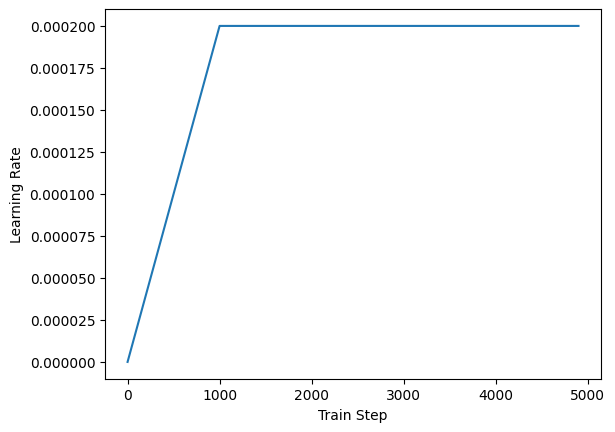

In [16]:
schedule = WarmupSchedule()
x = range(0, 5_000, 100)
y = [keras.ops.convert_to_numpy(schedule(step)) for step in x]
plt.plot(x, y)
plt.xlabel("Train Step")
plt.ylabel("Learning Rate")
plt.show()

#### Fitting the language model

In [17]:
num_epochs = 8
learning_rate = 0.001

# with Mini-C4, we do only one pass over the entire dataset!
steps_per_epoch = num_train_batches // num_epochs
validation_steps = num_val_batches

model.compile(
    optimizer=tf.keras.optimizers.Adam(schedule),
    # we use the class here, with `from_logits`: softmax will be applied internally
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        # will be `keras.metrics.SparseCategoricalAccuracy()` under the hood
        "accuracy",
    ],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=num_epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            MODELS_DIR / f"{MODEL_NAME}-gpt.keras",
            monitor="val_loss",
            save_best_only=True,
        )
    ],
)

Epoch 1/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 644s 77ms/step - accuracy: 0.2002 - loss: 5.2723 - val_accuracy: 0.2781 - val_loss: 4.3490
Epoch 2/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 553s 75ms/step - accuracy: 0.2850 - loss: 4.2738 - val_accuracy: 0.3142 - val_loss: 4.0177
Epoch 3/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 555s 75ms/step - accuracy: 0.3066 - loss: 4.0604 - val_accuracy: 0.3279 - val_loss: 3.8778
Epoch 4/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 554s 75ms/step - accuracy: 0.3173 - loss: 3.9540 - val_accuracy: 0.3369 - val_loss: 3.7899
Epoch 5/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 558s 76ms/step - accuracy: 0.3240 - loss: 3.8849 - val_accuracy: 0.3431 - val_loss: 3.7271
Epoch 6/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 561s 76ms/step - accuracy: 0.3287 - loss: 3.8353 - val_accuracy: 0.3480 - val_loss: 3.6871
Epoch 7/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 557s 76ms/step - accuracy: 0.3334 - loss: 3.7950 - val_accuracy: 0.3513 - val_loss: 3.6486
Epoch 8/8
7351/7351 ━━━━━━━━━━━━━━━━━━━━ 557s 76ms/step - accuracy: 0.3356 -

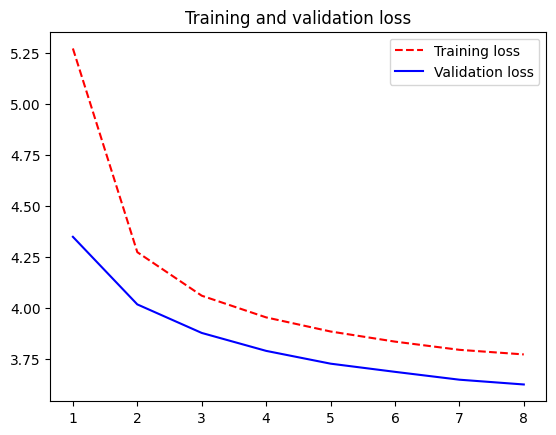

In [18]:
plot_history(history, "loss")

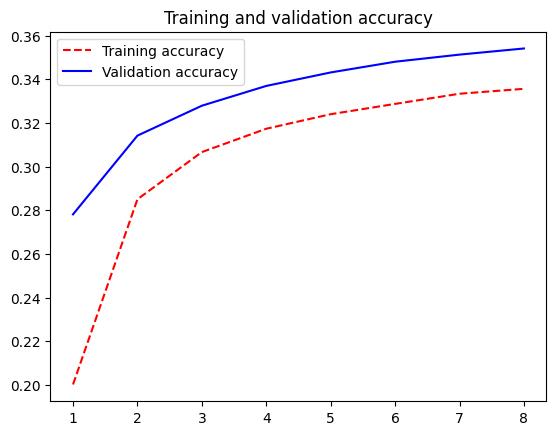

In [48]:
plot_history(history, "accuracy")

In [19]:
model = keras.models.load_model(MODELS_DIR /f"{MODEL_NAME}-gpt.keras")
stats = model.evaluate(val_ds, steps=validation_steps)

500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3541 - loss: 3.6251


### Generative decoding

### Generating text with our LLM

In [23]:
def generate(prompt, max_length=64):
    tokens = list(keras.ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    for _ in range(max_length - prompt_length):
        prediction = model(keras.ops.convert_to_numpy([tokens]))
        prediction = keras.ops.convert_to_numpy(prediction[0, -1])
        tokens.append(np.argmax(prediction).item())
    return tokenizer.detokenize(tokens)

In [24]:
prompt = "A piece of advice"
print(generate(prompt))

A piece of advice to you.
I’m a big fan of the 1990s and 1990s, and I’m a fan of the 1990s and 1990s. I’m a fan of the 1990


In [25]:
def compiled_generate(prompt, max_length=64):
    tokens = list(keras.ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = model.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        tokens[i] = np.argmax(prediction).item()
    return tokenizer.detokenize(tokens)

In [27]:
import timeit
tries = 10
timeit.timeit(lambda: generate(prompt), number=tries) / tries

10.200569685700065

In [28]:
import timeit
tries = 10
timeit.timeit(lambda: compiled_generate(prompt), number=tries) / tries

4.556506282299961

In [29]:
def compiled_generate(prompt, sample_fn, max_length=64):
    tokens = list(keras.ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = model.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        next_token = keras.ops.convert_to_numpy(sample_fn(prediction))
        tokens[i] = np.array(next_token).item()
    return tokenizer.detokenize(tokens)

In [30]:
def greedy_search(preds):
    return keras.ops.argmax(preds)

print(compiled_generate(prompt, greedy_search))

A piece of advice to you.
I’m a big fan of the 1990s and 1990s, and I’m a fan of the 1990s and 1990s. I’m a fan of the 1990


In [31]:
def random_sample(preds, temperature=1.0):
    preds = preds / temperature
    return keras.random.categorical(preds[None, :], num_samples=1)[0]

In [32]:
print(compiled_generate(prompt, random_sample))

'A piece of advice to me about one other flower in the family. What should I expect? I hope it’ll inspish your patience with your dream life.\nGlad I’re so proud that my little one will be immensely interested. Who would have thought of the summer time I’d'

In [33]:
from functools import partial
print(compiled_generate(prompt, partial(random_sample, temperature=2.0)))

A piece of advice sheld pull off asstellen te priisen by assess conception Motマému Ad viehnabeth professacht долж disordinarily Sozial fiddle ü Branch part sol progetti aktress Serwendung contrimentqué Musgehish bib Naturuning von Па ЕллаIBognIR Lithzeug compañDoc die dry orlegate


In [34]:
print(compiled_generate(prompt, partial(random_sample, temperature=0.8)))

A piece of advice for the barn after the assembled Japanese dome was installed.
The workers were also responsible for the 2014 war.
The officers had been appointed to the academy in 1979. The two were also awarded $3000 for the dome


In [35]:
print(compiled_generate(prompt, partial(random_sample, temperature=0.2)))

A piece of advice to the people who have been in the past.
The first thing I do is to make sure that I have the right to do it. I have to be careful not to let the people know what they are doing.
I have to be careful not to let the people know what they are


In [36]:
def top_k(preds, k=5, temperature=1.0):
    preds = preds / temperature
    top_preds, top_indices = keras.ops.top_k(preds, k=k, sorted=False)
    choice = keras.random.categorical(top_preds[None, :], num_samples=1)[0]
    return keras.ops.take_along_axis(top_indices, choice, axis=-1)

In [37]:
print(compiled_generate(prompt, partial(top_k, k=5)))

A piece of advice to you?
We are always looking to provide our services.
The best part of the project is that we do not offer any kind of service, so we do offer a full range of services for you.
If you have questions about our services or if you need help, contact us.<


In [38]:
print(compiled_generate(prompt, partial(top_k, k=20)))

A piece of advice to the public, and to get out of the box, we have not had a lot of other information about the area and our community.
To get a little bit of advice in the comments, the public’s comments were very close, and as with most of the commentators (and many


In [39]:
print(compiled_generate(prompt, partial(top_k, k=5, temperature=0.5)))

A piece of advice, I’d love to hear from you.
A couple of days ago I was thinking of a new book. I’d like to write a book that I can read. I’m going to write a book that I can read. I’m going to write a book that I


## Save models to Google Drive


In [47]:
EXPORT=False

if EXPORT:
    # zip models
    !zip {MODEL_NAME}-gpt.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp {MODEL_NAME}-gpt.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models